In [1]:
import pandas as pd
from pathlib import Path 
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory Data Analysis

This notebook explores historical real estate data used to develop a model for predicting home closing prices.  
## 1. Dataset Overview
The dataset consists of monthly CSV files containing historical real estate property records and their final sales prices (`ClosePrice`). The data is sourced from California Regional Multiple Listing Service (CRMLS) and covers January 2024 through April 2026.

Each CSV file represents one month of data. The monthly files are loaded and divided chronologically into training, validation, and test sets. 

In [2]:
# Create a Path object to the folder containing the monthly CSV files
data_path = Path("../data")

# Get all the CSV files from the data folder and sort them chronologically by filename
csv_files = sorted(data_path.glob("*.csv"))

### Train, Validation, and Test Split

The data is split chronologically rather than random to prevent future market conditions from leaking into the training .

- **Training set (Jan 2024 - Feb 2026):** All months except the two most recent complete months.
- **Validation set (Mar 2026):** The second-most-recent complete month, used for model selection and hyperparameter tuning.
- **Test set (April 2026):** The most recent complete month, reserved for final model evaluation.

In [3]:
# Split the monthly CSV files into training, validation, and test sets
train_files = csv_files[:-2]
validation_file = csv_files[-2]
test_file = csv_files[-1]

A `SourceMonth` column is added to each monthly training file based on its filename to identify the month and year the data came from. The monthly files are then combined into a single DataFrame for analysis.  

In [4]:
# Read each monthly training file into a DataFrame
read_train_csv_files = []

for file in train_files:
    monthly_data = pd.read_csv(file)

    # Extract the year and month from the CSV filename
    source_month = file.stem.replace("CRMLSSold", "").replace("_filled", "")
    monthly_data["SourceMonth"] = source_month[:4] + "-" + source_month[4:6]
    
    read_train_csv_files.append(monthly_data)
    
# Combine the monthly training DataFrames into a single DataFrame
initial_data = pd.concat(read_train_csv_files, ignore_index=True)

/var/folders/s8/2hb9crtx0f59zm5tv6jsyvhm0000gn/T/ipykernel_36345/2764230712.py:5: DtypeWarning: Columns (2,36,39,56,74) have mixed types. Specify dtype option on import or set low_memory=False.
  monthly_data = pd.read_csv(file)
/var/folders/s8/2hb9crtx0f59zm5tv6jsyvhm0000gn/T/ipykernel_36345/2764230712.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  monthly_data = pd.read_csv(file)
/var/folders/s8/2hb9crtx0f59zm5tv6jsyvhm0000gn/T/ipykernel_36345/2764230712.py:5: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  monthly_data = pd.read_csv(file)


In [5]:
initial_data["SourceMonth"].unique()

array(['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06',
       '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12',
       '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06',
       '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12',
       '2026-01', '2026-02'], dtype=object)

In [6]:
initial_data.columns.to_list()

['Flooring',
 'ViewYN',
 'WaterfrontYN',
 'BasementYN',
 'PoolPrivateYN',
 'OriginalListPrice',
 'ListingKey',
 'ListAgentEmail',
 'CloseDate',
 'ClosePrice',
 'ListAgentFirstName',
 'ListAgentLastName',
 'Latitude',
 'Longitude',
 'UnparsedAddress',
 'PropertyType',
 'LivingArea',
 'ListPrice',
 'DaysOnMarket',
 'ListOfficeName',
 'BuyerOfficeName',
 'CoListOfficeName',
 'ListAgentFullName',
 'CoListAgentFirstName',
 'CoListAgentLastName',
 'BuyerAgentMlsId',
 'BuyerAgentFirstName',
 'BuyerAgentLastName',
 'FireplacesTotal',
 'AssociationFeeFrequency',
 'AboveGradeFinishedArea',
 'ListingKeyNumeric',
 'MLSAreaMajor',
 'TaxAnnualAmount',
 'CountyOrParish',
 'MlsStatus',
 'ElementarySchool',
 'AttachedGarageYN',
 'ParkingTotal',
 'BuilderName',
 'PropertySubType',
 'LotSizeAcres',
 'SubdivisionName',
 'BuyerOfficeAOR',
 'YearBuilt',
 'BuyerAgencyCompensationType',
 'StreetNumberNumeric',
 'ListingId',
 'BathroomsTotalInteger',
 'City',
 'BuyerAgencyCompensation',
 'TaxYear',
 'BuildingA

In [7]:
initial_data.shape

(568074, 85)

### State Filtering 

Since the project focuses on California residential properties, records with a `StateOrProvince` value other than `CA` were removed. Of the `568,074` initial records, `76` non-California records were removed, leaving `567,998` records for further analysis.

In [8]:
initial_data["StateOrProvince"].value_counts()

StateOrProvince
CA    567998
AZ        16
NV         8
OK         7
TX         6
OS         6
FL         5
HI         4
MO         3
CO         3
ID         3
AR         2
TN         1
MT         1
NJ         1
OR         1
VA         1
ME         1
MI         1
NY         1
GA         1
AL         1
OH         1
LA         1
NM         1
Name: count, dtype: int64

In [9]:
non_ca_count = (initial_data["StateOrProvince"] != "CA").sum()
print(f"Non-California records removed: {non_ca_count}")

Non-California records removed: 76


In [10]:
initial_data = initial_data[initial_data["StateOrProvince"] == "CA"].copy()
display(initial_data.shape)

(567998, 85)

In [11]:
# Check the data types of the listing and closing date columns
initial_data[["ListingContractDate", "CloseDate"]].dtypes

ListingContractDate    object
CloseDate              object
dtype: object

In [12]:
# Convert ListingContractDate and CloseDate to datetime types
initial_data["CloseDate"] = pd.to_datetime(initial_data["CloseDate"])
initial_data["ListingContractDate"] = pd.to_datetime(initial_data["ListingContractDate"])                                   

In [13]:
initial_data.describe()

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,...,ListingContractDate,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,5.663580e+05,5.679980e+05,567998,5.679910e+05,563132.000000,563209.000000,5.278730e+05,5.671240e+05,567998.000000,0.0,...,567919,2482.000000,0.0,453879.000000,5.157590e+05,301129.000000,495342.000000,391634.000000,5.153200e+05,0.0
mean,9.078456e+05,1.093788e+09,2025-01-21 11:50:17.406398976,8.760292e+05,34.569945,-118.505790,3.565698e+03,8.400072e+05,43.089071,NaN,...,2024-11-05 19:52:01.714892032,106.427160,NaN,1.365106,4.859028e+04,1.932099,1.766575,185.050237,4.718374e+05,NaN
min,0.000000e+00,4.214490e+08,2024-01-01 00:00:00,0.000000e+00,-117.472493,-177.646696,0.000000e+00,0.000000e+00,-288.000000,NaN,...,1984-08-28 00:00:00,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,6.500000e+04,1.073317e+09,2024-07-08 00:00:00,5.500000e+04,33.739171,-118.581543,1.183000e+03,6.500000e+04,9.000000,NaN,...,2024-05-01 00:00:00,0.000000,NaN,1.000000,4.941000e+03,1.000000,1.000000,0.000000,5.181000e+03,NaN
50%,6.400000e+05,1.093011e+09,2025-01-21 00:00:00,6.300000e+05,34.042362,-118.060181,1.580000e+03,6.299900e+05,22.000000,NaN,...,2024-10-26 00:00:00,0.000000,NaN,1.000000,7.021000e+03,2.000000,2.000000,0.000000,7.282000e+03,NaN
75%,1.089000e+06,1.114484e+09,2025-08-04 00:00:00,1.070000e+06,34.415587,-117.328218,2.150000e+03,1.050000e+06,54.000000,NaN,...,2025-05-20 00:00:00,0.000000,NaN,2.000000,1.144000e+04,3.000000,2.000000,295.000000,1.287125e+04,NaN
max,1.390000e+09,1.155025e+09,2026-02-28 00:00:00,9.895000e+08,157.000000,329.000000,9.090909e+08,1.375000e+08,12430.000000,NaN,...,2026-04-20 00:00:00,17424.000000,NaN,2.000000,9.187423e+08,3333.000000,600.000000,750000.000000,5.193920e+09,NaN
std,5.851817e+06,3.206750e+07,NaN,5.357615e+06,1.650040,3.114051,1.251463e+06,1.273545e+06,69.695343,NaN,...,NaN,803.870375,NaN,0.481460,2.282158e+06,6.374106,3.907855,1665.433911,2.085269e+07,NaN


## Duplicate Records

Duplicate property transactions are identified using `UnparsedAddress` and `CloseDate`. The address filed is first examined for missing or invalid values before duplicate records are removed.

In [14]:
# Check for duplicate property records based on addess and close date
initial_data[["UnparsedAddress", "CloseDate"]].duplicated().sum()

np.int64(3292)

In [15]:
# Check for missing values in the fileds used to identify duplicates
print(initial_data["UnparsedAddress"].isna().sum())
print(initial_data["CloseDate"].isna().sum())

857
0


In [16]:
# Display all records involved in duplicate address and close date combinations
duplicate_records = initial_data[initial_data.duplicated(subset=["UnparsedAddress", "CloseDate"], keep=False)].\
                                              sort_values(["UnparsedAddress", "CloseDate"])
duplicate_records[["UnparsedAddress", "CloseDate", "ClosePrice"]].head(20)

,UnparsedAddress,CloseDate,ClosePrice
82856,Carl,2024-04-29,30000.0
82858,Carl,2024-04-29,30000.0
186710,Eagle Peak Road,2024-08-16,30048.0
186712,Eagle Peak Road,2024-08-16,48315.0
155138,Hubbard Street,2024-07-09,1787500.0
155150,Hubbard Street,2024-07-09,1787500.0
131114,Madrone Avenue,2024-06-17,8000.0
131115,Madrone Avenue,2024-06-17,4000.0
283758,Sierra Vista Avenue,2025-01-07,2050000.0
286590,Sierra Vista Avenue,2025-01-07,2998000.0


In [17]:
# Inspect short address values for potential invalid entries
addresses = initial_data["UnparsedAddress"].dropna().str.strip().astype(str)

addresses[addresses.str.len() <= 3].value_counts()

UnparsedAddress
0 0    21
0 .     4
N/A     2
0 ,     1
0 x     1
E       1
1 -     1
0 -     1
/       1
0 I     1
Name: count, dtype: int64

Records with missing or clearly invalid address, such as `0 --`, `0 0`, `N/A` or '/', were excluded from the duplicate check because these values cannot reliably identify a property.

In [18]:
# Identify records with valid addresses for duplicate detection
invalid_addresses = ["0 0", "0 .", "N/A", "0 ,", "0 x", "E", "1 -", "0 --", "/", "0 I"]

valid_address = (initial_data["UnparsedAddress"].notna() &\
                ~initial_data["UnparsedAddress"].isin(invalid_addresses))

In [19]:
duplicate_count = initial_data.loc[valid_address].duplicated(subset=["UnparsedAddress", "CloseDate"]).sum()

print(f"Duplicate records without invalid addresses›: {duplicate_count}")

Duplicate records without invalid addresses›: 2911


Using valid addresses, `2,911` duplicate records were identified based on the same address and closing date. Of the `567,998` records before duplicate removal, `2,911` records were removed, leaving `565,087` records for further analysis.

In [20]:
# Identify duplicate propery records while retaining the first occurrence
duplicate_records = (valid_address & initial_data.duplicated(subset=["UnparsedAddress", "CloseDate"], keep="first"))

# Calculate the number and percentage of records to be removed
duplicate_records_removed = duplicate_records.sum() 
duplicate_records_removed_percentage = (duplicate_records_removed / len(initial_data)) * 100

print(f"Duplicate records removed: {duplicate_records_removed}")
print(f"Percentage removed: {duplicate_records_removed_percentage:.4f}%")

Duplicate records removed: 2911
Percentage removed: 0.5125%


In [21]:
# Remove identified duplicate records
initial_data = initial_data[~duplicate_records].copy()
display(initial_data.shape)

(565087, 85)

## 2. Analysis Scope

The objective of this project is to predict the closing price of any single residential property in California based on its characteristics at the time of the query. Therefore, the training data is filtered to retain only records corresponding to single residential properties. Of the `565,087` records before property-type filtering, `280,370` records were removed, leaving `284,717` records for further analysis.

In [22]:
# Filter the training data to retain only records corresponding to single residential properties
training_data = initial_data[(initial_data["PropertyType"] == "Residential") &\
                            (initial_data["PropertySubType"] == "SingleFamilyResidence")]
display(initial_data.head())
display(training_data.shape)

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,SourceMonth,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,6472.0,NaN,NaN,True,True,2024-01,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,2024-01-24,950.0,...,NaN,52320.0,NaN,False,False,2024-01,NaN,NaN,NaN,NaN
2,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,2024-01-16,45000.0,...,NaN,217364.0,NaN,False,False,2024-01,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,2024-01-08,141500.0,...,NaN,217800.0,NaN,False,False,2024-01,NaN,NaN,NaN,NaN
4,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,2024-01-17,15000.0,...,0.0,108883.0,NaN,False,False,2024-01,NaN,NaN,NaN,NaN


(284717, 85)

Several features contain very high levels of missingness. Columns with more than 90% missing values are identified for further review and potiential removal during preprocessing.

In [23]:
# Summarize the count and percentage of missing values for each candidate feature
missing_summary = pd.DataFrame({"MissingCount": training_data.isna().sum(),\
                                "MissingPercent": training_data.isna().mean() * 100})
missing_summary = missing_summary.sort_values("MissingPercent", ascending=False)
missing_summary

,MissingCount,MissingPercent
AboveGradeFinishedArea,284717,100.0
TaxAnnualAmount,284717,100.0
MiddleOrJuniorSchoolDistrict,284717,100.0
TaxYear,284717,100.0
CoveredSpaces,284717,100.0
...,...,...
ListingContractDate,0,0.0
DaysOnMarket,0,0.0
ListPrice,0,0.0
BedroomsTotal,0,0.0


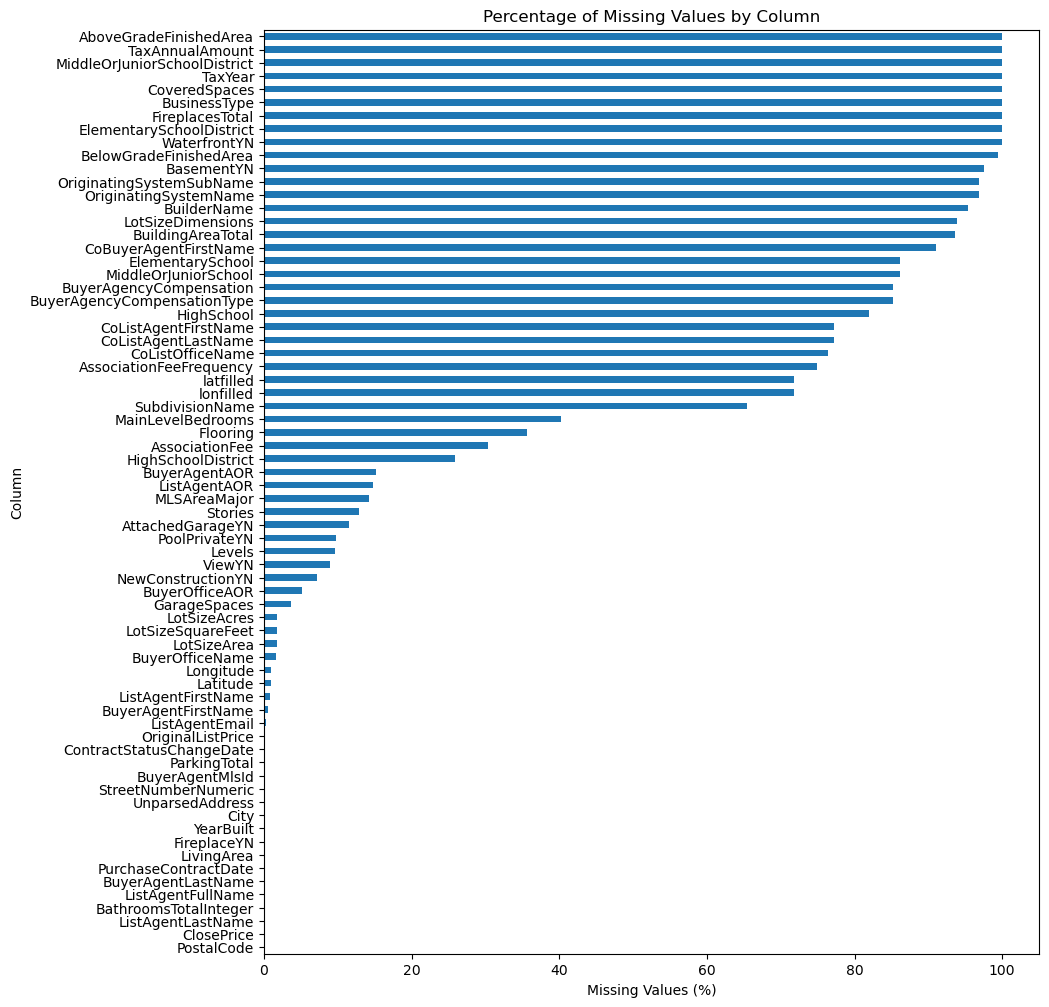

In [24]:
# Keep only columns that contains missing values
missing_plot = missing_summary[missing_summary["MissingPercent"] > 0]
#Plot missing percentage for each column
missing_plot["MissingPercent"].sort_values().plot(kind="barh", figsize=(10, 12))

plt.xlabel("Missing Values (%)")
plt.ylabel("Column")
plt.title("Percentage of Missing Values by Column")
plt.show()

Columns with more than 90% missing values were identified as candidates for removal during preprocessing. These features contain insufficient observed data for reliable use and will be reviewed before the final preprocessing decisions are applied.

In [25]:
high_missing = missing_summary[missing_summary["MissingPercent"] > 90]
high_missing

,MissingCount,MissingPercent
AboveGradeFinishedArea,284717,100.000000
TaxAnnualAmount,284717,100.000000
MiddleOrJuniorSchoolDistrict,284717,100.000000
TaxYear,284717,100.000000
CoveredSpaces,284717,100.000000
BusinessType,284717,100.000000
FireplacesTotal,284717,100.000000
ElementarySchoolDistrict,284717,100.000000
WaterfrontYN,284591,99.955746
BelowGradeFinishedArea,282981,99.390272


A subset of candidate features was initially selected based on the dataset metadata and their potential relevance to `ClosePrice`. 

In [26]:
key_columns = ["AttachedGarageYN", "BasementYN", "BathroomsTotalInteger", "BedroomsTotal",\
               "BuildingAreaTotal", "City", "CountyOrParish", "ClosePrice", "CloseDate", "FireplaceYN",\
               "Flooring", "GarageSpaces", "Latitude", "Longitude", "LivingArea", "ListingContractDate", "Levels",\
               "LotSizeSquareFeet", "LotSizeAcres", "NewConstructionYN", "ParkingTotal", "PoolPrivateYN", "PostalCode",\
               "Stories", "SourceMonth", "ViewYN", "YearBuilt", "PropertyType", "PropertySubType", "UnparsedAddress"]

In [27]:
training_data = training_data[key_columns].copy()

In [28]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 284717 entries, 5 to 568062
Data columns (total 30 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   AttachedGarageYN       251873 non-null  object        
 1   BasementYN             6829 non-null    object        
 2   BathroomsTotalInteger  284668 non-null  float64       
 3   BedroomsTotal          284717 non-null  float64       
 4   BuildingAreaTotal      17988 non-null   float64       
 5   City                   284478 non-null  object        
 6   CountyOrParish         284717 non-null  object        
 7   ClosePrice             284715 non-null  float64       
 8   CloseDate              284717 non-null  datetime64[ns]
 9   FireplaceYN            284538 non-null  object        
 10  Flooring               183129 non-null  object        
 11  GarageSpaces           274144 non-null  float64       
 12  Latitude               282167 non-null  float64  

In [29]:
training_data.shape

(284717, 30)

### Date Consistency

`ListingContractDate` and `CloseDate` are examined for chronological inconsistencies.  Records where `CloseDate` occurs before `ListingContractDate` are considered logically inconsistent and are identified for removal. 

In [30]:
# Identify records where the close data occurs before the listing contract date
invalid_date_order = (training_data["CloseDate"] < training_data["ListingContractDate"])
invalid_date_order.sum()

np.int64(39)

In [31]:
training_data.loc[invalid_date_order, ["ListingContractDate", "CloseDate", "ClosePrice", "UnparsedAddress"]].head(10) 

,ListingContractDate,CloseDate,ClosePrice,UnparsedAddress
52,2024-01-31,2024-01-30,2160000.0,17555 Luna de Miel
149,2024-01-26,2024-01-25,2705000.0,13913 Recuerdo Drive
112559,2024-06-20,2024-06-13,715000.0,6439 Jackson Dr
163391,2024-08-14,2024-08-13,5600000.0,2477 Avenida De La Playa
191650,2024-10-02,2024-09-19,1305000.0,1579 Oak Grove Drive
191951,2024-09-30,2024-09-05,995000.0,2328 Griffith Park Boulevard
192787,2024-09-28,2024-09-24,1275000.0,7817 Vicksburg Avenue
209258,2024-10-11,2024-10-10,5200000.0,2572 Bentley Ridge Drive
218308,2024-10-17,2024-10-09,1903500.0,2067 Hetebrink Street
232126,2024-11-18,2024-11-15,4275000.0,7740 46 Eads Ave


A total of `39` records were identified where `CloseDate` occurs before `ListingContractDate`, indicating a chronological inconsistency. Of the `284,717` records before date filtering, `39` records were removed, leaving `284,678` records for further analysis.

In [32]:
# Calculate the number and percentage of records to be removed
date_removed_count = invalid_date_order.sum()
date_removed_percentage = (date_removed_count / len(training_data)) * 100

print(f"Records removed: {date_removed_count}")
print(f"Percentage removed: {date_removed_percentage:.4}%")

# Remove records with invalid date order (ListingContractDate after CloseDate)
training_data = training_data[~invalid_date_order].copy()

Records removed: 39
Percentage removed: 0.0137%


In [33]:
training_data.shape

(284678, 30)

### Target Variable Cleaning 

Records with a missing `ClosePrice` or a `ClosePrice` less than or equal to zero are considered invalid for the prediction objective and are removed. A total of `3` records were removed, leaving `284,675` records for further analysis.

In [34]:
# Identify records with invalid or missing ClosePrice values
invalid_close_price = (training_data["ClosePrice"].isna() |\
                      (training_data["ClosePrice"] <= 0))

# Calculate the number and percentage of records to be removed
close_price_removed = invalid_close_price.sum()
close_price_removed_percentage = (close_price_removed / len(training_data)) * 100

print(f"Records removed: {close_price_removed}")
print(f"Percentage removed: {close_price_removed_percentage:.4}%")

# Remove records with invalid or missing ClosePrice Values
training_data = training_data[~invalid_close_price].copy()

Records removed: 3
Percentage removed: 0.001054%


### Target Variable Analysis

The distribution and range of `ClosePrice` are examined to identify potential data-quality issues and extreme values before modeling.

In [35]:
training_data["ClosePrice"].describe()

count    2.846750e+05
mean     1.287453e+06
std      5.211126e+06
min      1.150000e+00
25%      6.250000e+05
50%      8.900000e+05
75%      1.427455e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

The initial distribution of `ClosePrice` is visualized before percentile filtering.

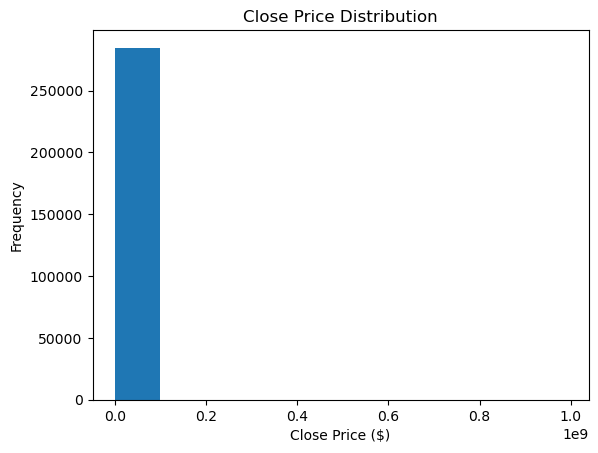

In [36]:
plt.hist(training_data["ClosePrice"])
plt.title("Close Price Distribution")
plt.xlabel("Close Price ($)")
plt.ylabel("Frequency")
plt.show()

The smallest and largest closing values are examined to better understand the extreme values observed in the target distribution. The `ClosePrice` values range from a minimum of `1.15` to a maximum of `989,500,000`.

In [37]:
training_data.nsmallest(5, "ClosePrice")["ClosePrice"]

270587      1.15
543168      1.75
108697    345.00
203942    380.00
480048    485.00
Name: ClosePrice, dtype: float64

In [38]:
training_data.nlargest(5, "ClosePrice")["ClosePrice"]

475560    989500000.0
350899    970000000.0
400421    900000000.0
447352    875000000.0
454029    835800000.0
Name: ClosePrice, dtype: float64

### Close Price Percentile Filtering 

To reduce the influence of extreme target values, the 0.5th and 99.5th percentile thresholds are calculated using the training set only. Observations outside these thresholds are removed.

Note: These thresholds are frozen and will later be applied unchanged to the validation and test sets.

In [39]:
# Calculate the 0.5th and 99.5th percentile thresholds for ClosePrice from training data
lower_threshold = training_data["ClosePrice"].quantile(0.005)
upper_threshold = training_data["ClosePrice"].quantile(0.995)

print("Lower threshold: ", lower_threshold)
print("Upper threshold: ", upper_threshold)

Lower threshold:  190000.0
Upper threshold:  8300000.0


Using the 0.5th and 99.5th percentile thresholds, `2,813` records were identified as extreme `ClosePrice` values. Of the `284,675` records before outlier filtering, `2,815` records were removed, leaving `281,862` records for further analysis. 

In [40]:
# Identify records outside the ClosePrice 0.5th and 99.5th percentile thresholds
price_outliers = ((training_data["ClosePrice"] < lower_threshold) |\
                      (training_data["ClosePrice"] > upper_threshold))

# Calculate the number and percentage of records to be removed
removed_count = price_outliers.sum()
removed_percentage = (removed_count / len(training_data)) * 100

print(f"Records removed: {removed_count}")
print(f"Percentage removed: {removed_percentage:.4}%")

# Remove records with invalid or missing ClosePrice Values
training_data = training_data[~price_outliers].copy()

Records removed: 2813
Percentage removed: 0.9881%


In [41]:
training_data.shape

(281862, 30)

The distribution is visualized again after percentile filtering to evaluate the target distribution after removing the extreme target values.

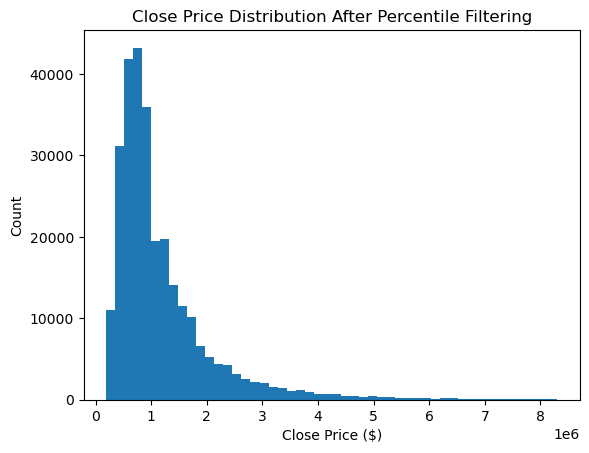

In [42]:
# Plot the distributaion of close price
plt.hist(training_data["ClosePrice"], bins=50)
plt.title("Close Price Distribution After Percentile Filtering")
plt.xlabel("Close Price ($)")
plt.ylabel("Count")
plt.show()

### Living Area

`LivingArea` is examined as a potential predictor of `ClosePrice`. The feature contains `117` missing values and `100` observations with a living area of `0` square feet. Since zero square footage is not logically consistent with the residential properties included in the analysis, these observations will be addressed during data cleaning.

In [43]:
training_data["LivingArea"].describe()

count    281745.000000
mean       2011.528781
std         939.651010
min           0.000000
25%        1378.000000
50%        1800.000000
75%        2409.000000
max       17153.000000
Name: LivingArea, dtype: float64

In [44]:
(training_data["LivingArea"]<= 0).sum()

np.int64(100)

In [45]:
training_data["LivingArea"].isna().sum()

np.int64(117)

The distribuation of `LivingArea` is right-skewed with most properties concentarted at lower square footage values and a smaller number of substantially larger properties.

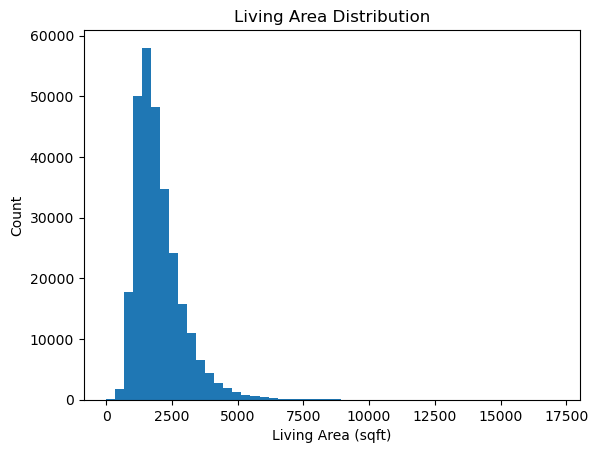

In [46]:
# Plot the distributaion of living area
plt.hist(training_data["LivingArea"], bins=50)
plt.title("Living Area Distribution")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Count")
plt.show()

### BedroomsTotal

`BedroomsTotal` contains no missing values. Most properties have between `2` and `5` bedrooms with `3` bedrooms being the most common count. There are `114` records with zero bedrooms and a small number with unusually high bedroom counts. These values will be further investigated when checking for logical inconsistencies between bedroom count and living area.  

In [47]:
training_data["BedroomsTotal"].describe()

count    281862.000000
mean          3.475527
std           0.942665
min           0.000000
25%           3.000000
50%           3.000000
75%           4.000000
max          45.000000
Name: BedroomsTotal, dtype: float64

In [48]:
training_data["BedroomsTotal"].isna().sum()

np.int64(0)

In [49]:
(training_data["BedroomsTotal"] == 0).sum()

np.int64(114)

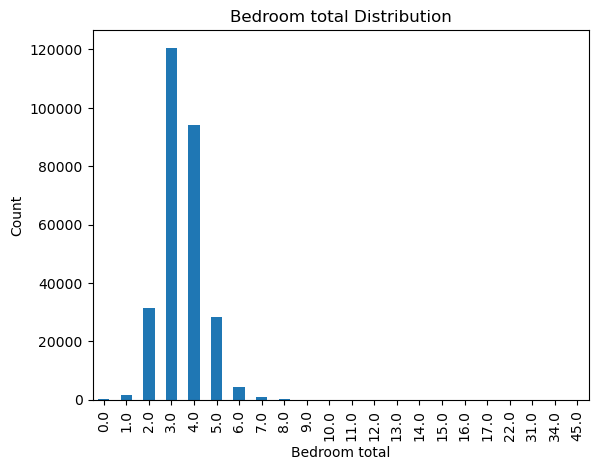

In [50]:
# Count the number of properties for each total bedroom count
total_bedroom_counts = training_data["BedroomsTotal"].value_counts().sort_index()

# Plot the distributaion of total bedroom counts 
total_bedroom_counts.plot(kind="bar")
plt.title("Bedroom total Distribution")
plt.xlabel("Bedroom total")
plt.ylabel("Count")
plt.show()

### BathroomsTotalInteger

`BathroomsTotalInteger` contains `48` missing values and `86` records with zero bathrooms. Most properties have between `1` and `4` bathrooms with `2` bathrooms being the most common count. A small number of observations have unusually high bathroom counts with a maximum of `175`. These values will be further investigated when checking for logical inconsistencies between bathroom count and living area.

In [51]:
training_data["BathroomsTotalInteger"].describe()

count    281814.000000
mean          2.597288
std           1.150750
min           0.000000
25%           2.000000
50%           2.000000
75%           3.000000
max         175.000000
Name: BathroomsTotalInteger, dtype: float64

In [52]:
training_data["BathroomsTotalInteger"].isna().sum()

np.int64(48)

In [53]:
(training_data["BathroomsTotalInteger"] == 0).sum()

np.int64(86)

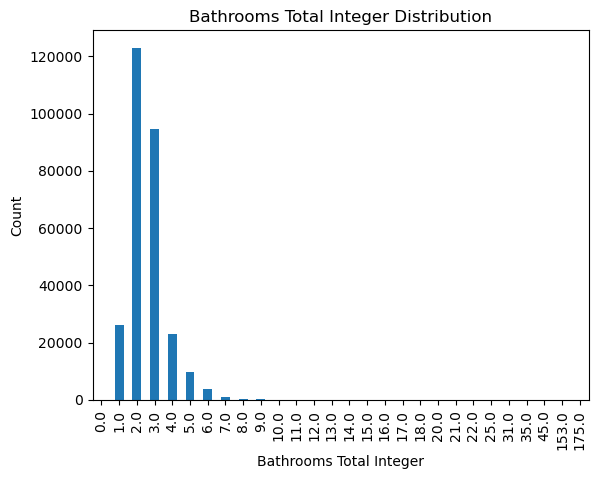

In [54]:
# Count the number of properties for each total bathroom count
total_bathroom_counts = training_data["BathroomsTotalInteger"].value_counts().sort_index()

# Plot the distributaion of total bathroom counts 
total_bathroom_counts.plot(kind="bar")
plt.title("Bathrooms Total Integer Distribution")
plt.xlabel("Bathrooms Total Integer")
plt.ylabel("Count")
plt.show()

### LotSizeSquareFeet

`LotSizeSquareFeet` contains `4,847` missing values and `142` observations with reported lot size of zero square feet. The feature is highly right-skewed and contains extremely large values with a maximum exceeding 2 billions square feet.

In [55]:
training_data["LotSizeSquareFeet"].describe()

count    2.770150e+05
mean     2.659580e+05
std      1.459851e+07
min      0.000000e+00
25%      5.663000e+03
50%      7.220000e+03
75%      1.020000e+04
max      2.087221e+09
Name: LotSizeSquareFeet, dtype: float64

In [56]:
training_data["LotSizeSquareFeet"].isna().sum()

np.int64(4847)

In [57]:
sum(training_data["LotSizeSquareFeet"] == 0)

142

In [58]:
# Calculate the 95th percentile for visualization
lot_size_95 = training_data["LotSizeSquareFeet"].quantile(0.95)
lot_size_95

np.float64(47480.4)

The histogram below displays observations up to the 95th percentile (approximately 47,480 square feet). This cutoff is used only for better visualization and does not remove observations from the training data.

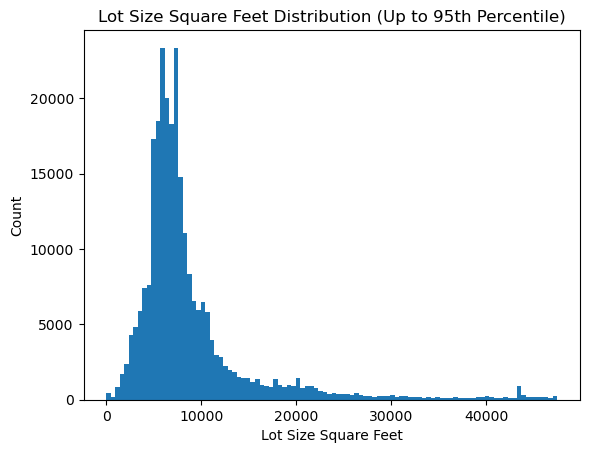

In [59]:
# Limit the plotted data to the 95th percentile
lot_size_plot = training_data.loc[training_data["LotSizeSquareFeet"] <= lot_size_95, "LotSizeSquareFeet"]
plt.hist(lot_size_plot, bins=100)
plt.title("Lot Size Square Feet Distribution (Up to 95th Percentile)")
plt.xlabel("Lot Size Square Feet")
plt.ylabel("Count")
plt.show()

In [60]:
training_data.nlargest(10, "LotSizeSquareFeet")[["LotSizeSquareFeet", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "ClosePrice"]]

,LotSizeSquareFeet,LivingArea,BedroomsTotal,BathroomsTotalInteger,ClosePrice
311387,2.087221e+09,3016.0,5.0,3.0,395000.0
496004,1.938943e+09,2825.0,4.0,4.0,2950000.0
228196,1.897474e+09,1775.0,3.0,3.0,495000.0
465663,1.897474e+09,4943.0,6.0,6.0,5500000.0
565513,1.897474e+09,3549.0,5.0,4.0,2863000.0
291257,1.821592e+09,7724.0,5.0,NaN,4500000.0
545766,1.802600e+09,3035.0,5.0,3.0,617500.0
78133,1.633500e+09,1660.0,4.0,3.0,905000.0
495662,1.432688e+09,912.0,2.0,1.0,315000.0
501671,1.306800e+09,3155.0,3.0,4.0,685000.0


### Missing Values

Missing values are examined across the candidate features to understand the extent of missingness before making data preprocessing decisions.

In [61]:
# Summarize the count and percentage of missing values for each candidate feature
missing_summary = pd.DataFrame({"MissingCount": training_data.isna().sum(),\
                                "MissingPercent": training_data.isna().mean() * 100})
missing_summary = missing_summary.sort_values("MissingPercent", ascending=False)
missing_summary

,MissingCount,MissingPercent
BasementYN,275299,97.671556
BuildingAreaTotal,264459,93.825702
Flooring,100345,35.600755
Stories,36040,12.786399
AttachedGarageYN,31730,11.257282
PoolPrivateYN,27283,9.679560
Levels,27060,9.600443
ViewYN,25368,9.000149
NewConstructionYN,20496,7.271644
GarageSpaces,10218,3.625178


### Monthly Sales Distribution

The number of single-family residential sales is examined across the training period to identify changes in sales volume over time. Monthly sales fluctuate throughout the dataset, with higher sales volumes generally observed during the spring and summer months and lower volumes around the beginning and end of the year. 

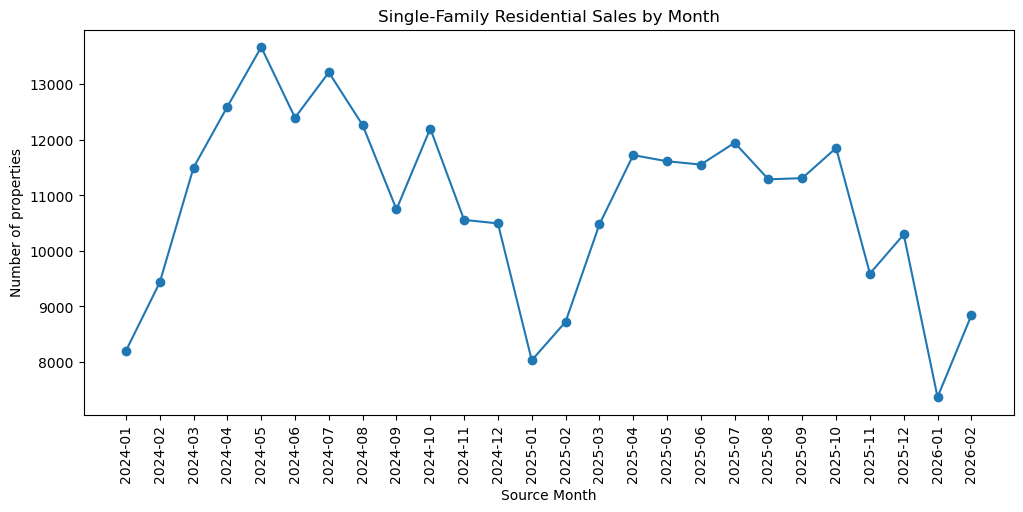

In [62]:
# Count the number of single-family residential sales in each month
monthly_sales = training_data["SourceMonth"].value_counts().sort_index()

# Plot the number of sales over time
monthly_sales.plot(kind="line", marker="o", figsize=(12, 5))
plt.title("Single-Family Residential Sales by Month")
plt.xlabel("Source Month")
plt.ylabel("Number of properties")
plt.xticks(ticks=range(len(monthly_sales)), labels=monthly_sales.index, rotation=90)
plt.show()

### Sales by City

The number of single-family residential sales varies considerably across cities. Los Angeles and San Diego have the largest number of observations among the top 20 citites, followed by San Jose. This indicates that the training data is not evenly distributed geographically with some cities contributing substantially more observations than others. 

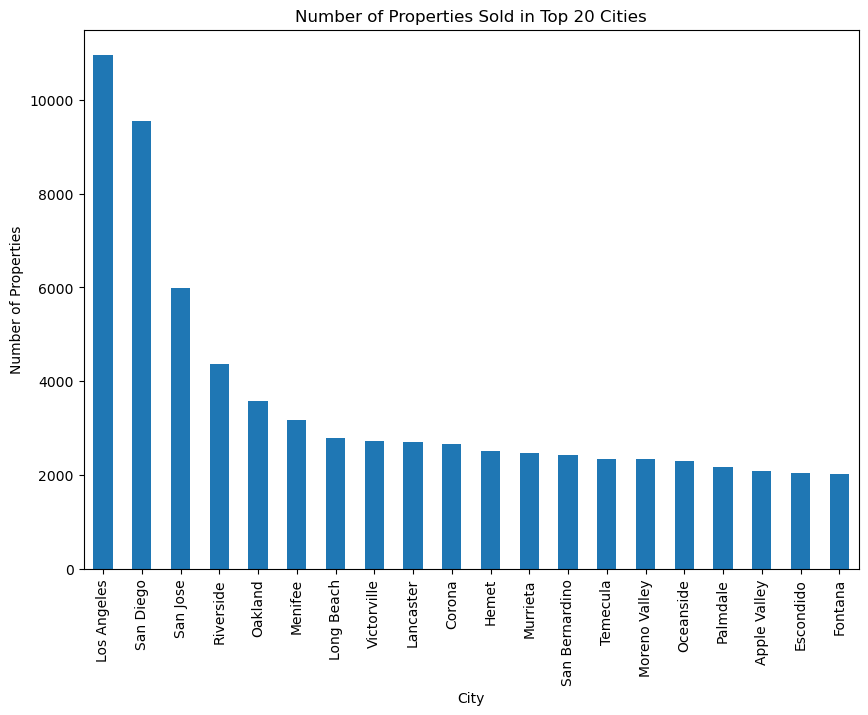

In [63]:
# Get the 20 cities with the most properties sold
top_cities = training_data["City"].value_counts().head(20)

# Plot the number of properties sold in each city
top_cities.sort_values(ascending=False).plot(kind="bar", figsize=(10, 7))

plt.title("Number of Properties Sold in Top 20 Cities")
plt.xlabel("City")
plt.ylabel("Number of Properties")
plt.show()

In [64]:
numeric_candidate_feature = ["BathroomsTotalInteger", "BedroomsTotal",\
               "LotSizeAcres", "GarageSpaces", "LivingArea",
               "LotSizeSquareFeet", "LotSizeAcres", "ParkingTotal", "YearBuilt"]

### Candidate Features and Close Price

The scatter plots show the relationships between the numeric candidate features and `ClosePrice`. `LivingArea` shows the clearest positive relationships with `ClosePrice`, while several othe features are affected by extreme values. 

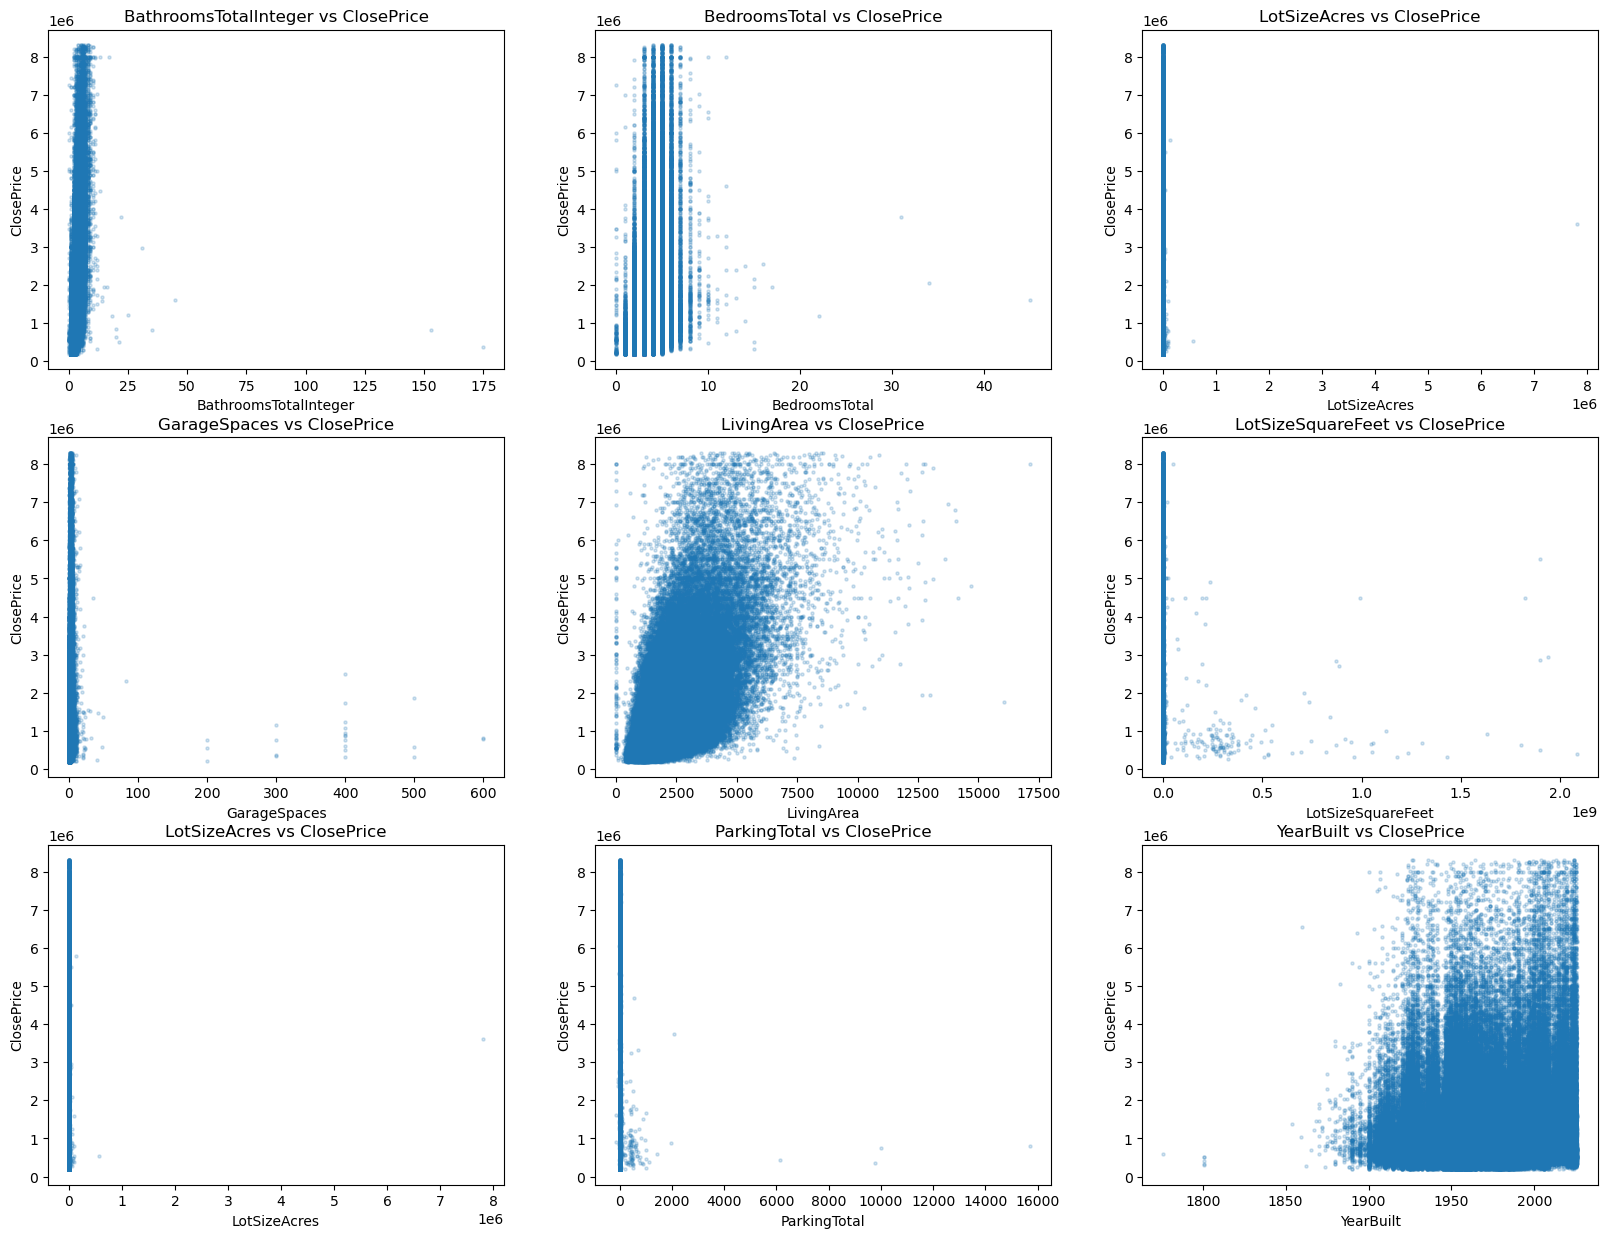

In [65]:
fig, axes = plt.subplots(3, 3, figsize=(20, 15))

# Plot each candidate feature against ClosePrice
for ax, feature in zip(axes.flatten(), numeric_candidate_feature):
    ax.scatter(training_data[feature], training_data["ClosePrice"], alpha=0.2, s=5)
    ax.set_title(f"{feature} vs ClosePrice")
    ax.set_xlabel(feature)
    ax.set_ylabel("ClosePrice")

plt.tight_layout
plt.show()   